# Programming Tutorial 6: AlexNet and Tricks for Deep Learning

```
Course: CSCI 4922/5922 Spring 2026, University of Colorado Boulder
TA: Everley Tseng
Email: Yu-Yun.Tseng@colorado.edu
* AI assistant was used in making this tutorial
```


## Overview

**Sections**:
- GPU computing resource
- AlexNet
- Load and fine-tune a pre-trained AlexNet

**Objectives**:
- Learn how to leverage the GPU resource on Colab
- Learn how to build AlexNet based on the architecture learned in the lecture
- Learn how to load a pretrained model and make predictions using the model
- Learn how to fine-tune a pretrained model


In [1]:
import torch
import torch.nn as nn

## GPU Computing Resource

GPUs are effective acceleration tools for model training compared to CPUs. Today, we'll learn how to leverage the Colab GPU resource and how to handle computing resources in your script.

### Colab GPU Computing Resource

The free Colab version supports limited usage of the `T4 GPU`. When you are not using the GPU resource, disconnect to the GPU runtime to save your hours. If you are on a paid plan, the Google Gemini Free Pro Plan for students, or other plans, you might have access to more GPUs and more hours.

To start using GPUs, change the runtime setting in the menu bar:

**Runtime** -> **Change runtime type** --> **GPU** (e.g., T4 GPU)

### GPU Computing Resource



Run the next cell to confirm the available device. If the GPU(s) are detected, this cell should print:
```
Using device: cuda
```
Otherwise, this will print:
```
Using device: cpu
```

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


As both CPUs and GPUs have computing power, it is crucial for us to make sure that the model parameters and training data are both loaded to the same device. This is why we need the variable `device` to be loaded to your script prior to creating/loading a model or a dataset. Examples of its usage are below:

```
# create a model
model = mymodel.to(device)

# load data
x_train = x_train.to(device)
y_train = y_train.to(device)
```

We will be seeing a lot of these conversions in today's script. You can experiment removing the `.to(device)` lines and observe the results.


This is no limited to Colab. If you are using other cloud or local computing resources, it is also important to handle the device distribution correctly to avoid runtime crashes.

## AlexNet

In this section, we'll be coding the famous AlexNet model!

Following the design of AlexNet, we will combine what we learned in the previous tutorials (e.g., `nn.Module`, layers, loss function, optimizer) to code it in PyTorch. Before starting to code, let's lay out the AlexNet architecture.

### Model Architecture

Familiarize yourself with the AlexNet architecture before coding:

#### **Input**

- Image size: 227 × 227 × 3 (RGB)

#### **Convolution Layers**
- Layer 1
  - Conv1: 96 filters, kernel 11×11, stride 4, padding 0
  - Activation: ReLU
  - MaxPool: 3×3, stride 2
  - LRN: Local Response Normalization
- Layer 2
  - Conv2: 256 filters, kernel 5×5, stride 1, padding 2
  - Activation: ReLU
  - MaxPool: 3×3, stride 2
  - LRN: Local Response Normalization
- Layer 3
  - Conv3: 384 filters, kernel 3×3, stride 1, padding 1
  - Activation: ReLU
- Layer 4
  - Conv4: 384 filters, kernel 3×3, stride 1, padding 1
  - Activation: ReLU
- Layer 5
  - Conv5: 256 filters, kernel 3×3, stride 1, padding 1
  - Activation: ReLU
  - MaxPool: 3×3, stride 2

#### **Classifier (Fully-Connected Layers)**
- Layer 6
  - Flatten
  - FC1: 4096 units
  - Activation: ReLU
  - Dropout: p = 0.5
- Layer 7
  - FC2: 4096 units
  - Activation: ReLU
  - Dropout: p = 0.5
- Layer 8 (Output Layer)
  - FC3: 1000 units (for ImageNet 1000 classes)
  - Output: logits (typically followed by softmax during evaluation)

In [ ]:
import torch
import torch.nn as nn

class AlexNetLRN(nn.Module):
    """
    AlexNet-style architecture (as in the original 2012 paper) with LRN.
    Assumes input images are 227x227 (so the final feature map is 6x6).
    """

    def __init__(self, num_classes=1000):
        super().__init__()

        # LRN hyperparameters used in the AlexNet paper:
        # n=5, alpha=1e-4, beta=0.75, k=2
        self.lrn1 = nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2.0)
        self.lrn2 = nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2.0)

        self.features = nn.Sequential(
            # Layer 1
            nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4, padding=0),
            nn.ReLU(inplace=True),
            self.lrn1,
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Layer 2
            nn.Conv2d(in_channels=96, out_channels=256, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            self.lrn2,
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Layer 3
            nn.Conv2d(in_channels=256, out_channels=384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            # Layer 4
            nn.Conv2d(in_channels=384, out_channels=384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            # Layer 5
            nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        # For 227x227 input, after conv/pool stack you get 256 x 6 x 6
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),

            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, num_classes)  # logits
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)  # flatten all but batch dimension
        x = self.classifier(x)
        return x


Print the architecture summary:

In [ ]:
!pip install torchsummary

In [ ]:
from torchsummary import summary

model = AlexNetLRN(num_classes=1000).to(device)
summary(model, (3, 227, 227))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 55, 55]          34,944
              ReLU-2           [-1, 96, 55, 55]               0
 LocalResponseNorm-3           [-1, 96, 55, 55]               0
 LocalResponseNorm-4           [-1, 96, 55, 55]               0
         MaxPool2d-5           [-1, 96, 27, 27]               0
            Conv2d-6          [-1, 256, 27, 27]         614,656
              ReLU-7          [-1, 256, 27, 27]               0
 LocalResponseNorm-8          [-1, 256, 27, 27]               0
 LocalResponseNorm-9          [-1, 256, 27, 27]               0
        MaxPool2d-10          [-1, 256, 13, 13]               0
           Conv2d-11          [-1, 384, 13, 13]         885,120
             ReLU-12          [-1, 384, 13, 13]               0
           Conv2d-13          [-1, 384, 13, 13]       1,327,488
             ReLU-14          [-1, 384,

### Dataset Preparation

Today, we will be using a dataset with color images.

Before preceeding to the following cells, please:

- download the dataset from this [link](https://o365coloradoedu-my.sharepoint.com/:u:/r/personal/yuts1923_colorado_edu/Documents/CSCI%205922/public/dataset.zip?csf=1&web=1&e=DKBsGv)
- upload it to your Google Drive
- unzip it
- and change `dataset_path` to your path

In [ ]:
# connect google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# change this to your path!!
dataset_path = '/content/drive/My Drive/Courses/CSCI 5922/CSCI 5922 SP25/Demo/dataset'

In [ ]:
json_path = f"{dataset_path}/image_labels.json"
image_path = f"{dataset_path}/images"

To load the dataset, we need to manually read the files. From the unzipped folder, we see the following data available:
- `images`
- `image_labels.json`

For open-source datasets, you can read their website for annotation structures. For your home-made dataset, you are able to come up with your own annotation structure. For instance, this dataset is structured in the following format:
```
<image_id>: {'file_name': <file_name>, 'label': <label>, 'class_name': <class_name>}
```

You can also read the data and print the first sample:

In [ ]:
import json

with open(json_path, "r") as f:
    dataset_dict = json.load(f)

print("Number of samples:", len(dataset_dict))
print("First item:", list(dataset_dict.items())[0])
print("Number of categories:", len(set([item["label"] for item in dataset_dict.values()])))

Number of samples: 100
First item: ('00003625', {'file_name': 'ILSVRC2012_val_00003625.JPEG', 'label': 113, 'class_name': 'snail'})
Number of categories: 10


Let's convert this data into a `list` format for the next step. There are only 10 categories in this dataset, so we need to convert `label` into values from 0 to 9.

In [ ]:
samples = []

# dictionaries for later conversion
unique_labels = sorted(set([item["label"] for item in dataset_dict.values()]))
label_to_new = {old: new for new, old in enumerate(unique_labels)} # for conversion
new_to_name = {label_to_new[item["label"]]: item["class_name"] for item in dataset_dict.values()}

# save data in samples
for key, item in dataset_dict.items():
    samples.append({
        "id": key,
        "file_name": item["file_name"],
        "label": label_to_new[item["label"]], # convert to new label
        "class_name": item["class_name"]
    })

print("First sample:", samples[0])

First sample: {'id': '00003625', 'file_name': 'ILSVRC2012_val_00003625.JPEG', 'label': 2, 'class_name': 'snail'}


In PyTorch, we often use the `Dataset` class to manage homegrown data. This step makes data processing easier as `Dataset` connects directly to the tool, `DataLoader`. `DataLoader` helps us with batching, shuffling, and loading data efficiently.

- [`Dataset`](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html)
- [`DataLoader`](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html)

To read an image, we often use the libraries `pillow` or `opencv`:
```
image = Image.open(img_path)
image = cv2.imread(img_path)
```

- [`PIL`](https://pillow.readthedocs.io/en/stable/reference/Image.html) (pillow)
- [`cv2`](https://docs.opencv.org/4.x/d4/da8/group__imgcodecs.html) (OpenCV)


When processing image data, we often use `torchvision.transforms`. This tool helps us resize and augment image data.

- [`torchvision.transforms`](https://docs.pytorch.org/vision/main/transforms.html) (often imported as `T`)


In [ ]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T

class MyDataset(Dataset):
    def __init__(self, samples, image_dir, transform=None):
        self.samples = samples
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        # get sample from data passed in
        sample = self.samples[idx]
        img_path = os.path.join(self.image_dir, sample["file_name"])

        # design your sample (e.g., image + label)
        image = Image.open(img_path).convert("RGB")
        label = sample["label"]

        # apply image transform
        if self.transform is not None:
            image = self.transform(image)

        return image, label

For image augmentation, the `torchvision.transforms` module can help us efficiently apply method such as the following ones:

- Horizontal / Vertical Flip
  ```
  T.RandomHorizontalFlip(p=0.5)
  T.RandomVerticalFlip(p=0.2)
  ```

- Random Crop (very common for CIFAR/ImageNet-style training)
  ```
  T.RandomCrop(crop_size)
  ```

- Rotation
  ```
  T.RandomRotation(degrees=15)
  ```

- Random Affine (translate/scale/shear)
  ```
  T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1))
  ```

- Gaussian Blur
  ```
  T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
  ```

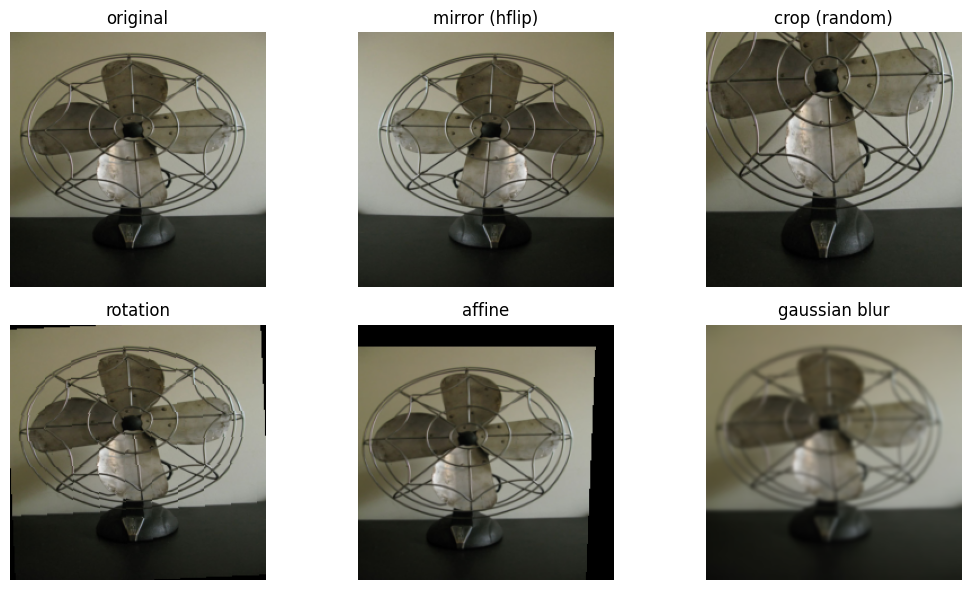

In [ ]:
import random
import matplotlib.pyplot as plt
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode

# apply all the augmentation methods here
aug_transforms = {
    "mirror (hflip)": T.Compose([
        T.Resize((227, 227)),
        T.RandomHorizontalFlip(p=1.0),
    ]),
    "crop (random)": T.Compose([
        T.Resize(256),
        T.RandomCrop(227),
    ]),
    "rotation": T.Compose([
        T.Resize((227, 227)),
        T.RandomRotation(degrees=20),
    ]),
    "affine": T.Compose([
        T.Resize((227, 227)),
        T.RandomAffine(
            degrees=0,
            translate=(0.10, 0.10),
            scale=(0.90, 1.10),
            shear=10,
            interpolation=InterpolationMode.BILINEAR,
        ),
    ]),
    "gaussian blur": T.Compose([
        T.Resize((227, 227)),
        T.GaussianBlur(kernel_size=7, sigma=(0.2, 2.0)),
    ]),
}

# Pick one sample image (PIL) from your dataset ----
item = random.choice(samples)
img_path = os.path.join(image_path, item["file_name"])
img = Image.open(img_path).convert("RGB")

# Visualize original + each augmentation
plt.figure(figsize=(11, 6))

# original
plt.subplot(2, 3, 1)
plt.imshow(T.Resize((227, 227))(img))
plt.title("original")
plt.axis("off")

# augmented versions
for i, (name, tfm) in enumerate(aug_transforms.items(), start=2):
    plt.subplot(2, 3, i)
    plt.imshow(tfm(img))
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()


For our training data, let's apply mirror and rotation:

In [ ]:
from torch.utils.data import DataLoader

# resize images to 227 x 227 (still with 3 channels)
transform = T.Compose([
    T.Resize((227, 227)),
    T.RandomHorizontalFlip(p=0.5),  # mirror
    T.RandomRotation(degrees=15),   # rotation
    T.ToTensor(),
])

# create the dataset
my_dataset = MyDataset(samples, image_path, transform=transform)

# create a data loader for your data
batch_size = 32
loader = DataLoader(my_dataset, batch_size=batch_size, shuffle=False)

# check the shapes of the first batch
x_batch, y_batch = next(iter(loader))
print("x_batch shape:", x_batch.shape)
print("y_batch shape:", y_batch.shape)
print("labels:", y_batch[:5])

x_batch shape: torch.Size([32, 3, 227, 227])
y_batch shape: torch.Size([32])
labels: tensor([2, 9, 7, 5, 6])


### Model Training

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as T

Design your own training code. This includes the loss function, optimizer, and training logistics. Different from the previous tutorials, we are using the data loading tool, `DataLoader`, today. Pay attention to the part where we load every batch from the data loader and accumulate the results for the entire epoch.

In [ ]:
def train_alexnet(model, train_loader, n_epochs=5, lr=1e-3):
    model = model.to(device)
    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

    model.train()
    for epoch in range(n_epochs):
        running_loss = 0.0
        running_acc = 0.0
        n_seen = 0

        # load batches from train
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            logits = model(x_batch)
            loss = loss_function(logits, y_batch)

            # back prop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # generate predictions
            with torch.no_grad():
                preds = logits.argmax(dim=1)
                acc = (preds == y_batch).float().mean().item()

            # update loss and accuracy from the batch
            running_loss += loss.item() * batch_size
            running_acc += acc * batch_size
            n_seen += batch_size

        # print every epoch (or every n epochs)
        print(f"[Epoch {epoch+1}] train loss: {running_loss/n_seen:.4f} | "
              f"train acc: {100*(running_acc/n_seen):.2f}%")

    return model

In [ ]:
# create model
model = AlexNetLRN(num_classes=10)

# train
model = train_alexnet(model, loader, n_epochs=5, lr=1e-2)

[Epoch 1] train loss: 2.3014 | train acc: 12.50%
[Epoch 2] train loss: 2.2980 | train acc: 19.53%
[Epoch 3] train loss: 2.2926 | train acc: 19.53%
[Epoch 4] train loss: 2.2868 | train acc: 19.53%
[Epoch 5] train loss: 2.2803 | train acc: 19.53%


Achieving a higher accuracy would require more training data and epochs. Due to limited time/resources, we will skip full convergence training in this tutorial.

### Model Evaluation

Similar to the training code, to calculate the accuracy, we will pass in data batch by batch (*with the same batch size*) and accumulate the results:

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        logits = model(x_batch)
        preds = logits.argmax(dim=1)

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

acc = correct / total
print(f"Eval accuracy: {100 * acc:.2f}%")

Eval accuracy: 11.00%


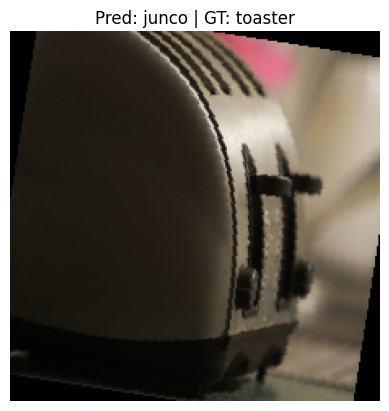

In [ ]:
import random, torch
import matplotlib.pyplot as plt

# assign a random sample
sample_ind = 37
x, y = my_dataset[sample_ind]

# get prediction
model.eval()
with torch.no_grad():
    x_sample = x.unsqueeze(0).to(device)
    pred = model(x_sample)
    pred = pred.argmax(dim=1).item()

# display
plt.figure()
plt.imshow(x.permute(1, 2, 0))
plt.axis("off")
plt.title(f"Pred: {new_to_name[pred]} | GT: {new_to_name[y]}")
plt.show()

## Pre-Trained AlexNet

Training AlexNet from scratch normally requires a large dataset, such as ImageNet with 1.2M images, and a lot of compute time. In practice, we often start from a pretrained model. This model's weights were already trained on a large dataset, so we can use it directly for prediction.


### PyTorch Built-in Models


PyTorch provides many commonly used architectures through `torchvision.models`. With one line, we can load a pretrained AlexNet and run inference.

- Models and pretrained weights on PyTorch: https://docs.pytorch.org/vision/main/models
- List of pretrained models: https://docs.pytorch.org/vision/0.9/models.html


In [ ]:
import torch, random
import matplotlib.pyplot as plt
import torchvision.transforms as T
from torchvision.models import alexnet, AlexNet_Weights

# Load pretrained AlexNet (trained on ImageNet)
weights = AlexNet_Weights.DEFAULT
model_pt = alexnet(weights=weights)
model_pt.eval()

# Use the pretrained model's recommended preprocessing
preprocess = weights.transforms()

### Prediction

Let's take a random sample and test the model on it:

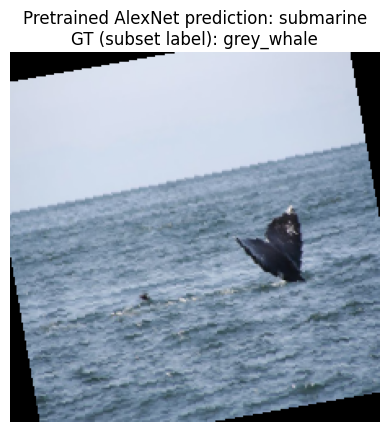

In [ ]:
# Pick a random image from your dataset
data_ind = 25

# Get x and y
x, y = my_dataset[data_ind]
x_in = preprocess(T.ToPILImage()(x)).unsqueeze(0)

# Prediction
with torch.no_grad():
    pred_idx = model_pt(x_in).argmax(dim=1).item()
pred_name = weights.meta["categories"][pred_idx]

# Visualize the image + prediction
plt.figure()
plt.imshow(x.permute(1, 2, 0))
plt.axis("off")
plt.title(f"Pretrained AlexNet prediction: {pred_name}\nGT (subset label): {new_to_name[y]}")
plt.show()


If we calculate the accuracy of this model, we can see that is performance is better than the model we were training. It will take a larger dataset with a lot more iterations for our AlexNet to get here!

In [ ]:
correct = 0
total = 0

for item in dataset_dict.values():
    # load image
    img_path = os.path.join(image_path, item["file_name"])
    image = Image.open(img_path).convert("RGB")

    # GT: remap ImageNet label -> 0..9
    y_true = label_to_new[item["label"]]

    # predict
    x = preprocess(image).unsqueeze(0)  # [1, 3, H, W]
    with torch.no_grad():
        pred_imagenet = model_pt(x).argmax(dim=1).item()  # 0..999

    # remap prediction into our 10-class space if possible
    if pred_imagenet in label_to_new:
        y_pred = label_to_new[pred_imagenet]
        correct += (y_pred == y_true)
    total += 1

acc = correct / total
print(f"Pretrained AlexNet accuracy on our 10-class subset: {acc*100:.2f}%")

Pretrained AlexNet accuracy on our 10-class subset: 62.00%


## Fine-Tuning Pretrained Model

Fine-tuning a pre-trained model on our dataset could be a lot more efficient than training the model from scratch. Using this pretrained AlexNet, let's fine-tune it on our 10-class dataset.

Before fine-tuning a model, we need to
1. Change the last layer into the size of our categories
2. Freeze layers that we do not wish to update parameters

In [ ]:
# Replace the last classifier layer (ImageNet 1000 -> your 10 classes)
model_pt.classifier[6] = nn.Linear(model_pt.classifier[6].in_features, 10)

# Freeze all earlier layers (feature extractor + earlier classifier layers)
for p in model_pt.parameters():
    p.requires_grad = False
for p in model_pt.classifier[6].parameters():  # only train the new last layer
    p.requires_grad = True

model_pt = model_pt.to(device)

**Model Fine-Tuning**

Train this model on the dataset:

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_pt.classifier[6].parameters(), lr=1e-2, momentum=0.9)

n_epochs = 5
for epoch in range(1, n_epochs + 1):
    model_pt.train()
    total_loss, total_correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model_pt(x)
        loss = loss_fn(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total += x.size(0)

    print(f"Epoch {epoch}/{n_epochs} | loss: {total_loss/total:.4f} | acc: {100*total_correct/total:.2f}%")

Epoch 1/5 | loss: 2.0795 | acc: 29.00%
Epoch 2/5 | loss: 0.8200 | acc: 76.00%
Epoch 3/5 | loss: 0.1868 | acc: 93.00%
Epoch 4/5 | loss: 0.1338 | acc: 94.00%
Epoch 5/5 | loss: 0.1943 | acc: 97.00%


We can see that the model converged a lot faster on the dataset than the model we tried to train from scratch!

## Review

In this tutorial, we (1) learned what vanishing gradients are and why they make deep networks hard to train, (2) implemented the full AlexNet architecture (including LRN), and (3) used PyTorch’s pretrained AlexNet to run inference without training from scratch.

For practice, you can try:
1. Initializing a model with large normal distribution and see if there is vanishing gradient.
2. Use a different activation function and see if there is vanishing gradient.
3. Train your AlexNet for more epochs and plot the learning curves.


For any questions and discussions regarding this tutorial, attend [TA office hours](https://docs.google.com/spreadsheets/d/1abWD9DJqjEGrCdr8VbZ3aiOhx4vpT1y0-LOoLWgPwZM/edit?usp=sharing) or create a post on [Piazza](https://piazza.com/colorado/spring2026/csci49225922/home) :) See you in the next tutorial!

\- Everley